In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset from the CSV file
telco_data=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Get the dimensions of the DataFrame
telco_data.shape

(7043, 21)

In [5]:
#Columns used in the Dataframe
telco_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [6]:
#Data types
telco_data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [7]:
# Descriptive Statistics
telco_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Text(0.5, 1.0, 'Count of TARGET variable per category')

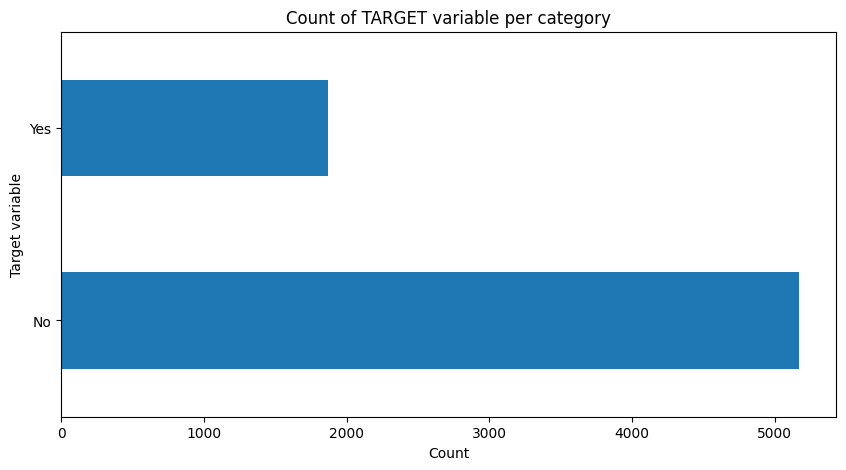

In [8]:
telco_data['Churn'].value_counts().plot(kind='barh',figsize=(10,5))
plt.xlabel("Count")
plt.ylabel("Target variable")
plt.title("Count of TARGET variable per category")

In [9]:
# Calculate the percentage of churned vs. non-churned customers
telco_data['Churn'].value_counts()/len(telco_data['Churn'])*100

,count
Churn,
No,73.463013
Yes,26.536987


In [10]:
# Count the occurrences of each unique value
telco_data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [11]:
# Get a concise summary of the DataFrame
telco_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
# Fraction of missing values
telco_data.isna().mean()*100

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


# DATA CLEANING

In [13]:
# Copy of the original DataFrame to perform data cleaning operations
telco_new_data=telco_data.copy()

In [14]:
# Convert 'TotalCharges' column to numeric and finding the missing values per column
telco_new_data.TotalCharges=pd.to_numeric(telco_new_data.TotalCharges,errors='coerce')
telco_new_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


*Note: There are 11 missing values in the Total Charges columns which should be removed*

In [15]:
# Display rows where 'TotalCharges' is null
telco_new_data.loc[telco_new_data['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [16]:
# Drop rows with any missing values
telco_new_data.dropna(inplace=True)

In [17]:
# Print the maximum value of the 'tenure' column
print(telco_new_data['tenure'].max())

72


In [18]:
# Define labels for tenure groups and create a new 'tenure_group' column by binning the 'tenure' column into defined groups
labels=["{0} - {1}".format(i,i+11) for i in range(1,72,12)]
telco_new_data['tenure_group']=pd.cut(telco_new_data.tenure,range(1,80,12),right=False,labels=labels)

In [19]:
# Occurrences of each tenure group
telco_new_data.tenure_group.value_counts()

,count
tenure_group,
1 - 12,2175
61 - 72,1407
13 - 24,1024
25 - 36,832
49 - 60,832
37 - 48,762


In [20]:
# Dropping 'customerID' and 'tenure' columns
telco_new_data.drop(columns=['customerID','tenure'],axis=1,inplace=True)
telco_new_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


# DATA EXPLORATION

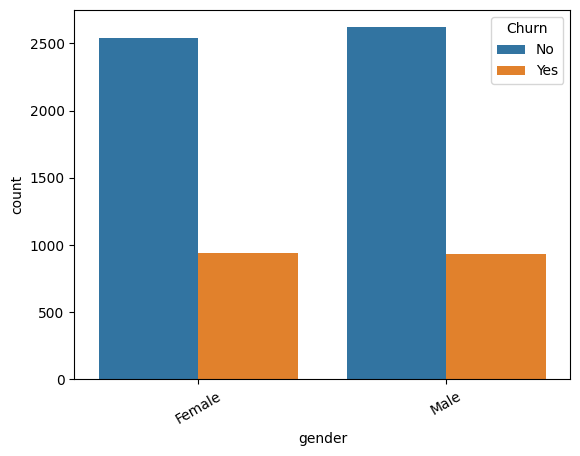

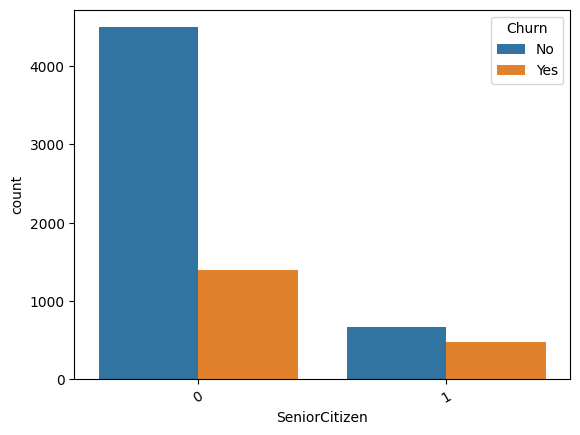

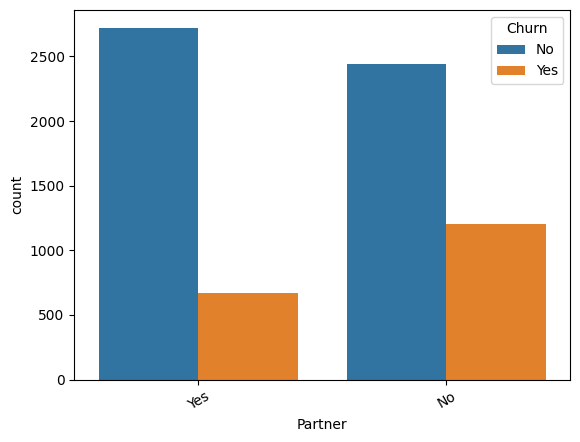

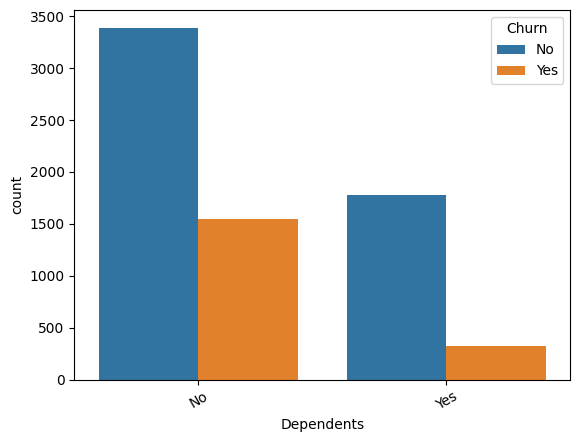

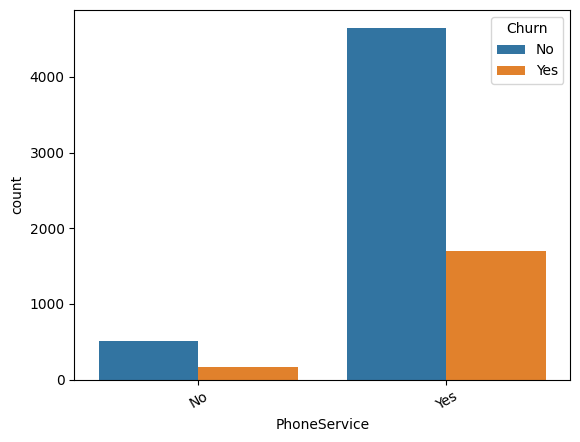

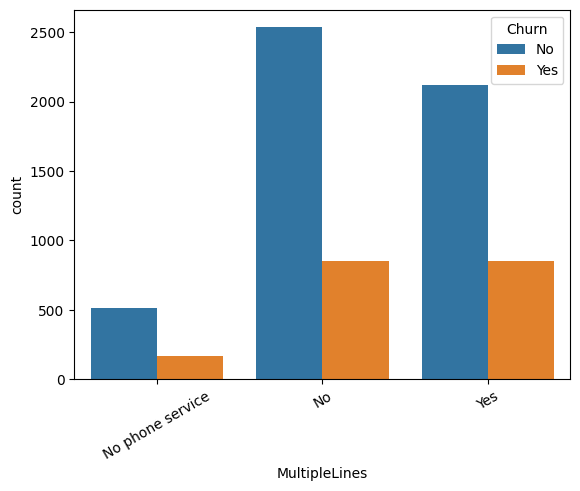

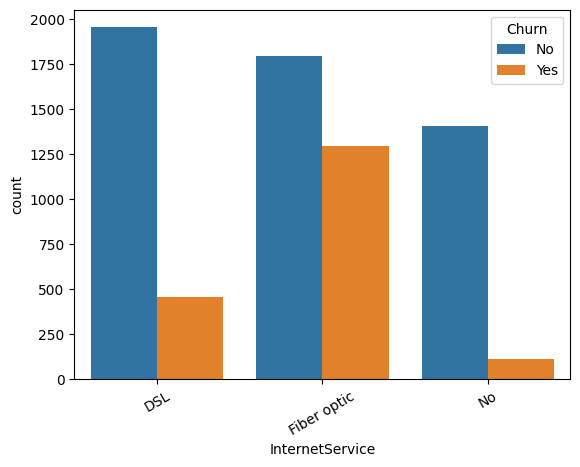

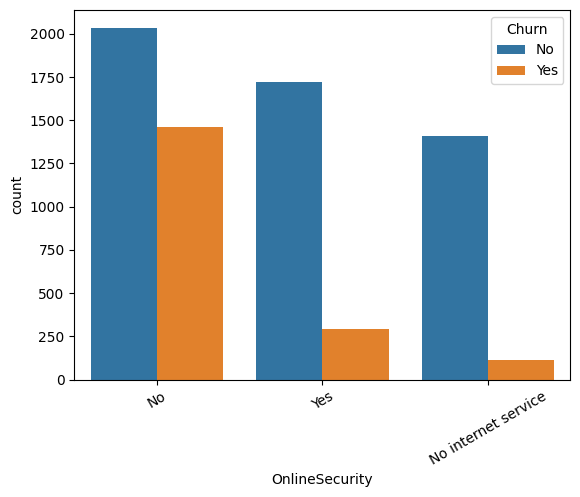

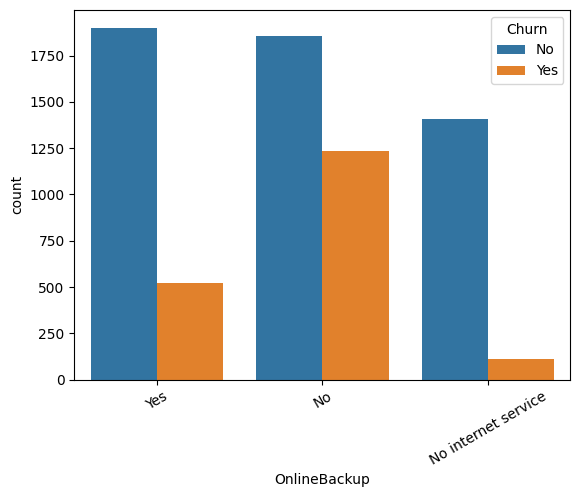

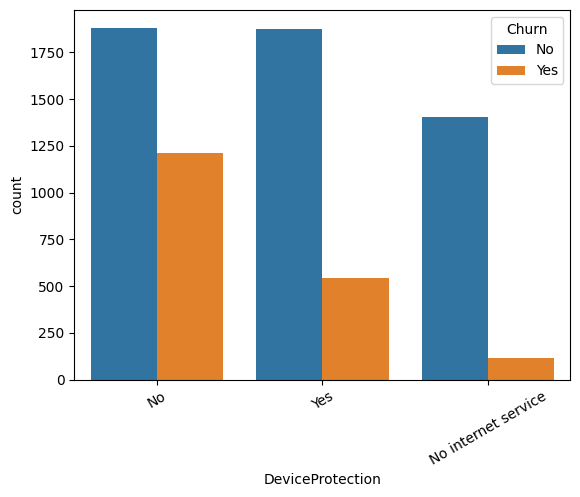

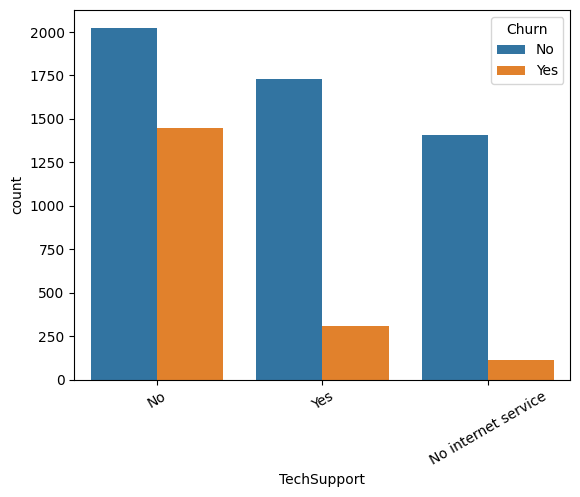

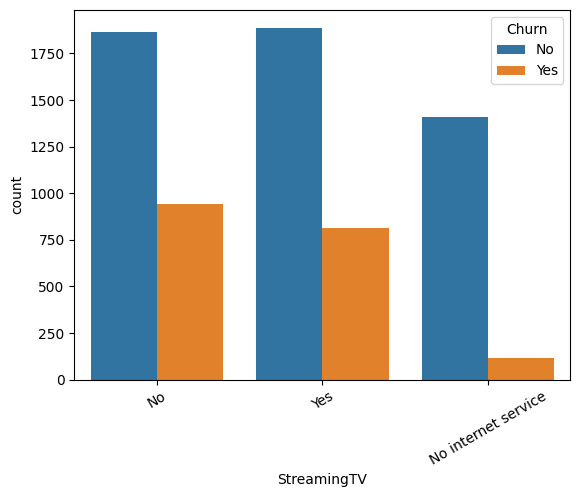

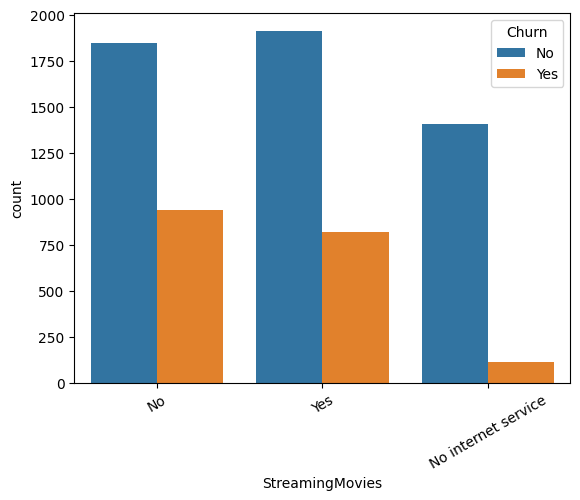

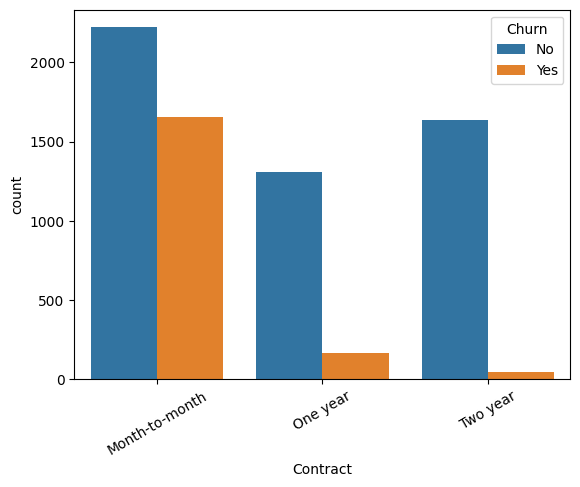

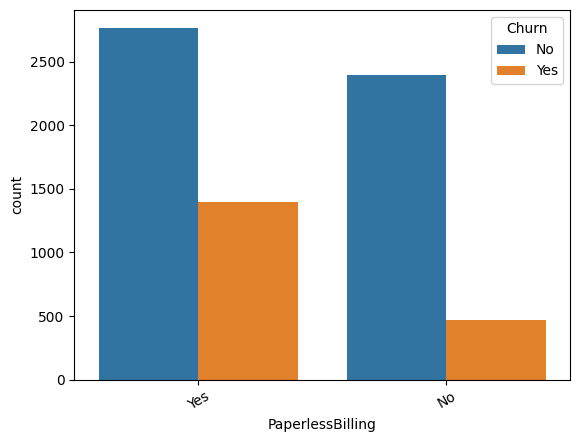

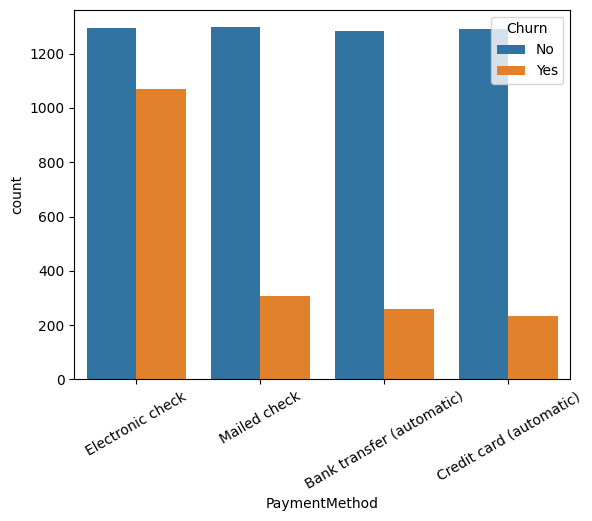

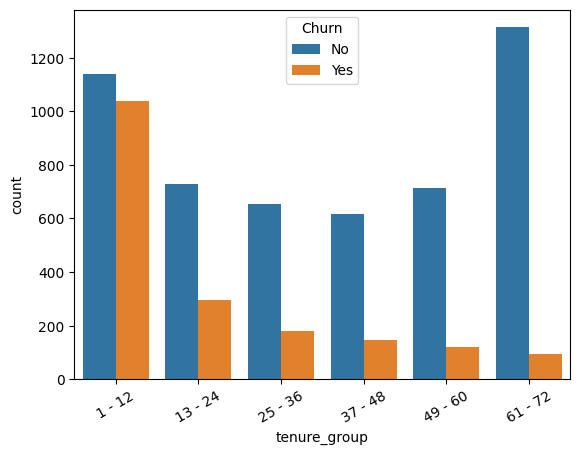

In [21]:
# Looping through categorical predictors and create countplots against 'Churn'
for i,predictor in enumerate(telco_new_data.drop(columns=['Churn','TotalCharges','MonthlyCharges'])):
  plt.figure(i)
  sns.countplot(data=telco_new_data,x=predictor,hue='Churn')
  plt.xticks(rotation=30)

In [22]:
# Converting the 'Churn' column to numerical format
telco_new_data['Churn']=np.where(telco_new_data.Churn=='Yes',1,0)

In [23]:

telco_new_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [24]:
# one-hot encoding on categorical columns to convert them into numerical format
telco_new_data_dummies=pd.get_dummies(telco_new_data)
telco_new_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

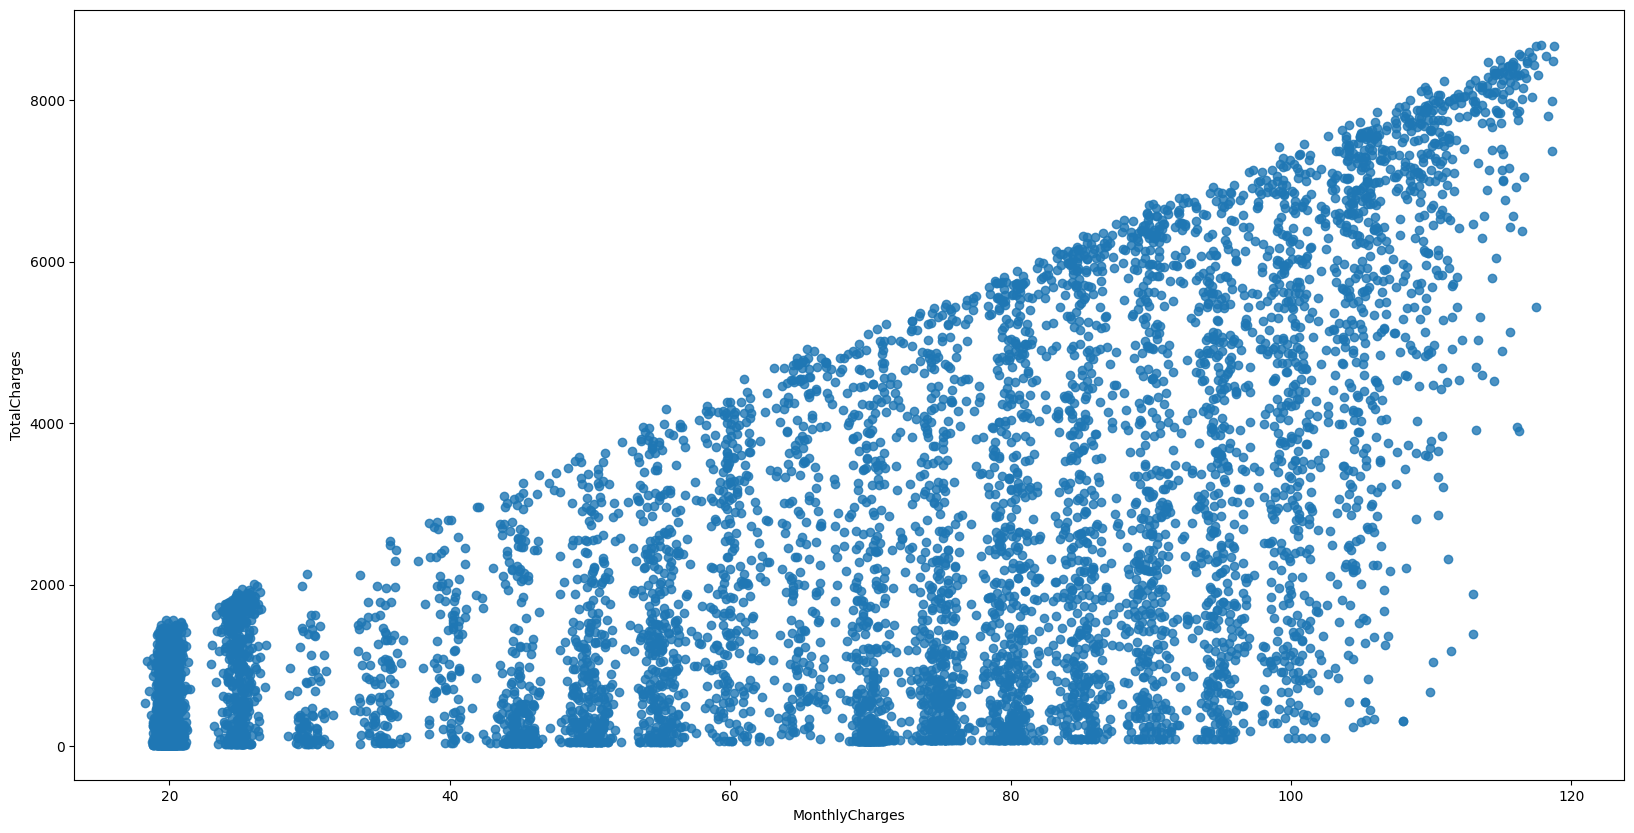

In [25]:
# Created a scatter plot to visualize the relationship between 'MonthlyCharges' and 'TotalCharges'
fig,ax=plt.subplots(figsize=(20,10))
sns.regplot(data=telco_new_data_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

Text(0.5, 1.0, 'total charges by churn')

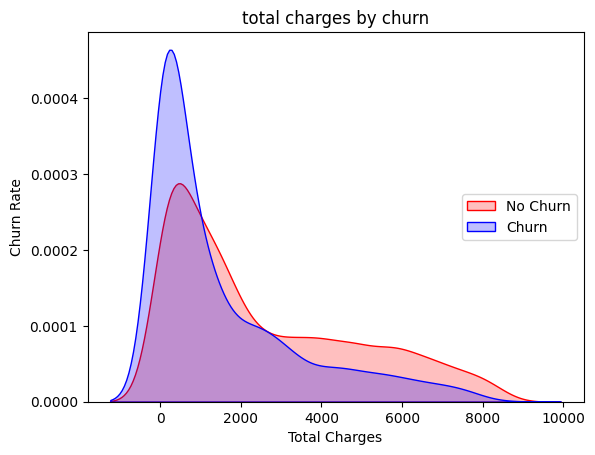

In [26]:
# Created KDE (Kernel Density Estimate) plots to compare 'TotalCharges' distribution for churned and non-churned customers
Charges=sns.kdeplot(data=telco_new_data_dummies.TotalCharges[(telco_new_data_dummies["Churn"]==0)],color="Red",fill=True)
Charges=sns.kdeplot(data=telco_new_data_dummies.TotalCharges[(telco_new_data_dummies["Churn"]==1)],ax=Charges,color="Blue",fill=True)

Charges.legend(["No Churn","Churn"],loc='right')
Charges.set_xlabel('Total Charges')
Charges.set_ylabel('Churn Rate')
Charges.set_title('total charges by churn')

<Axes: >

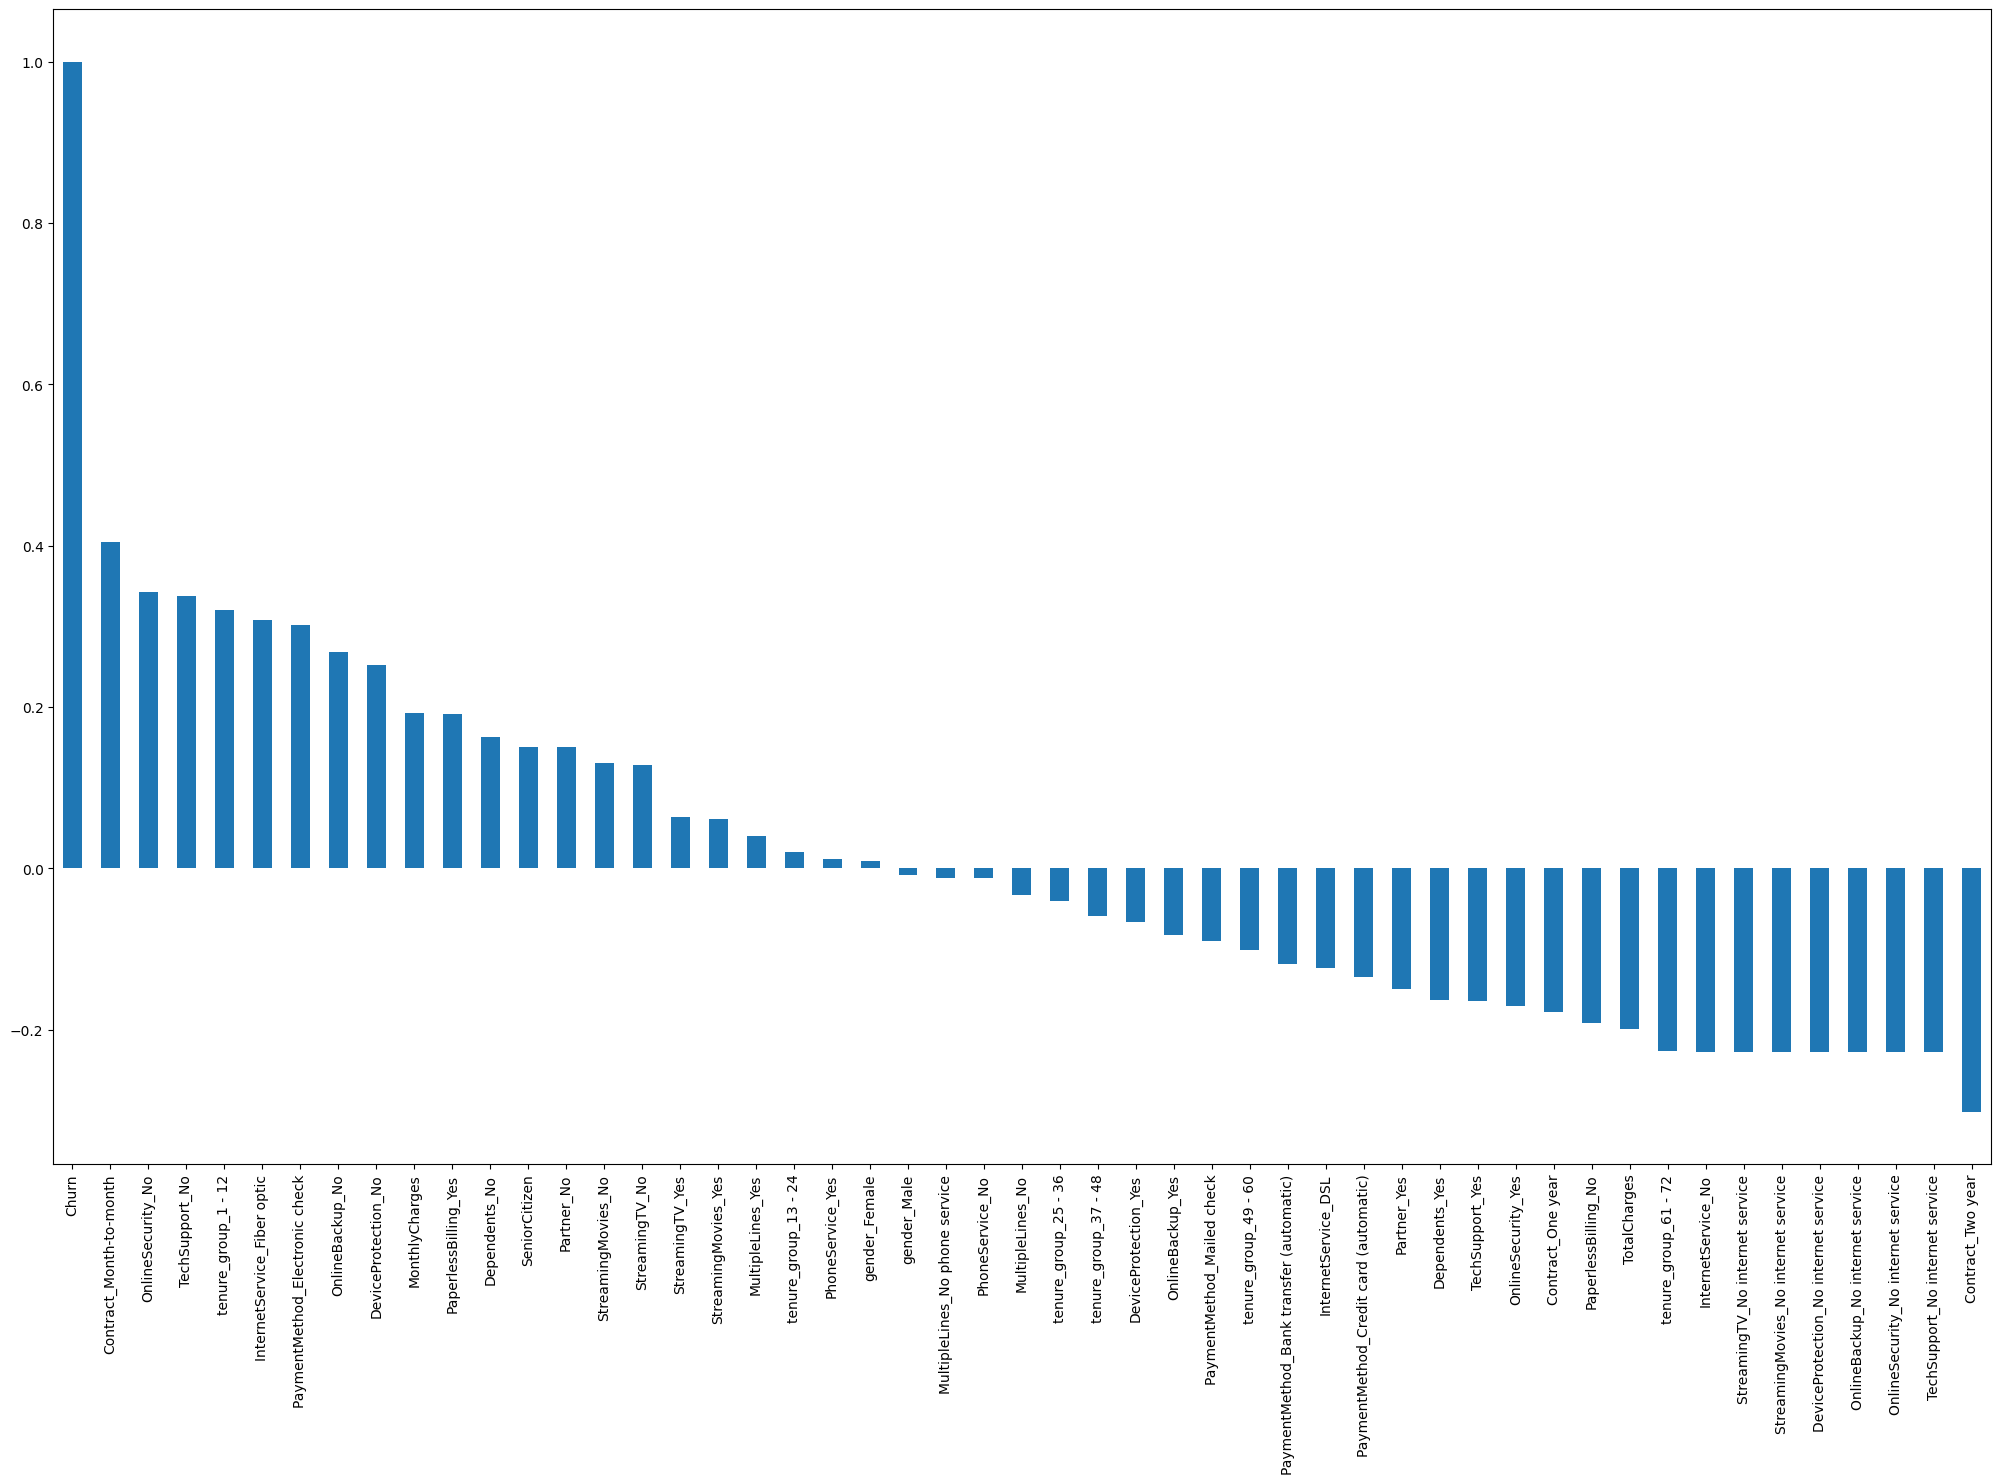

In [27]:
# correlation of each feature with 'Churn'
plt.figure(figsize=(25,15))
telco_new_data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

<Axes: >

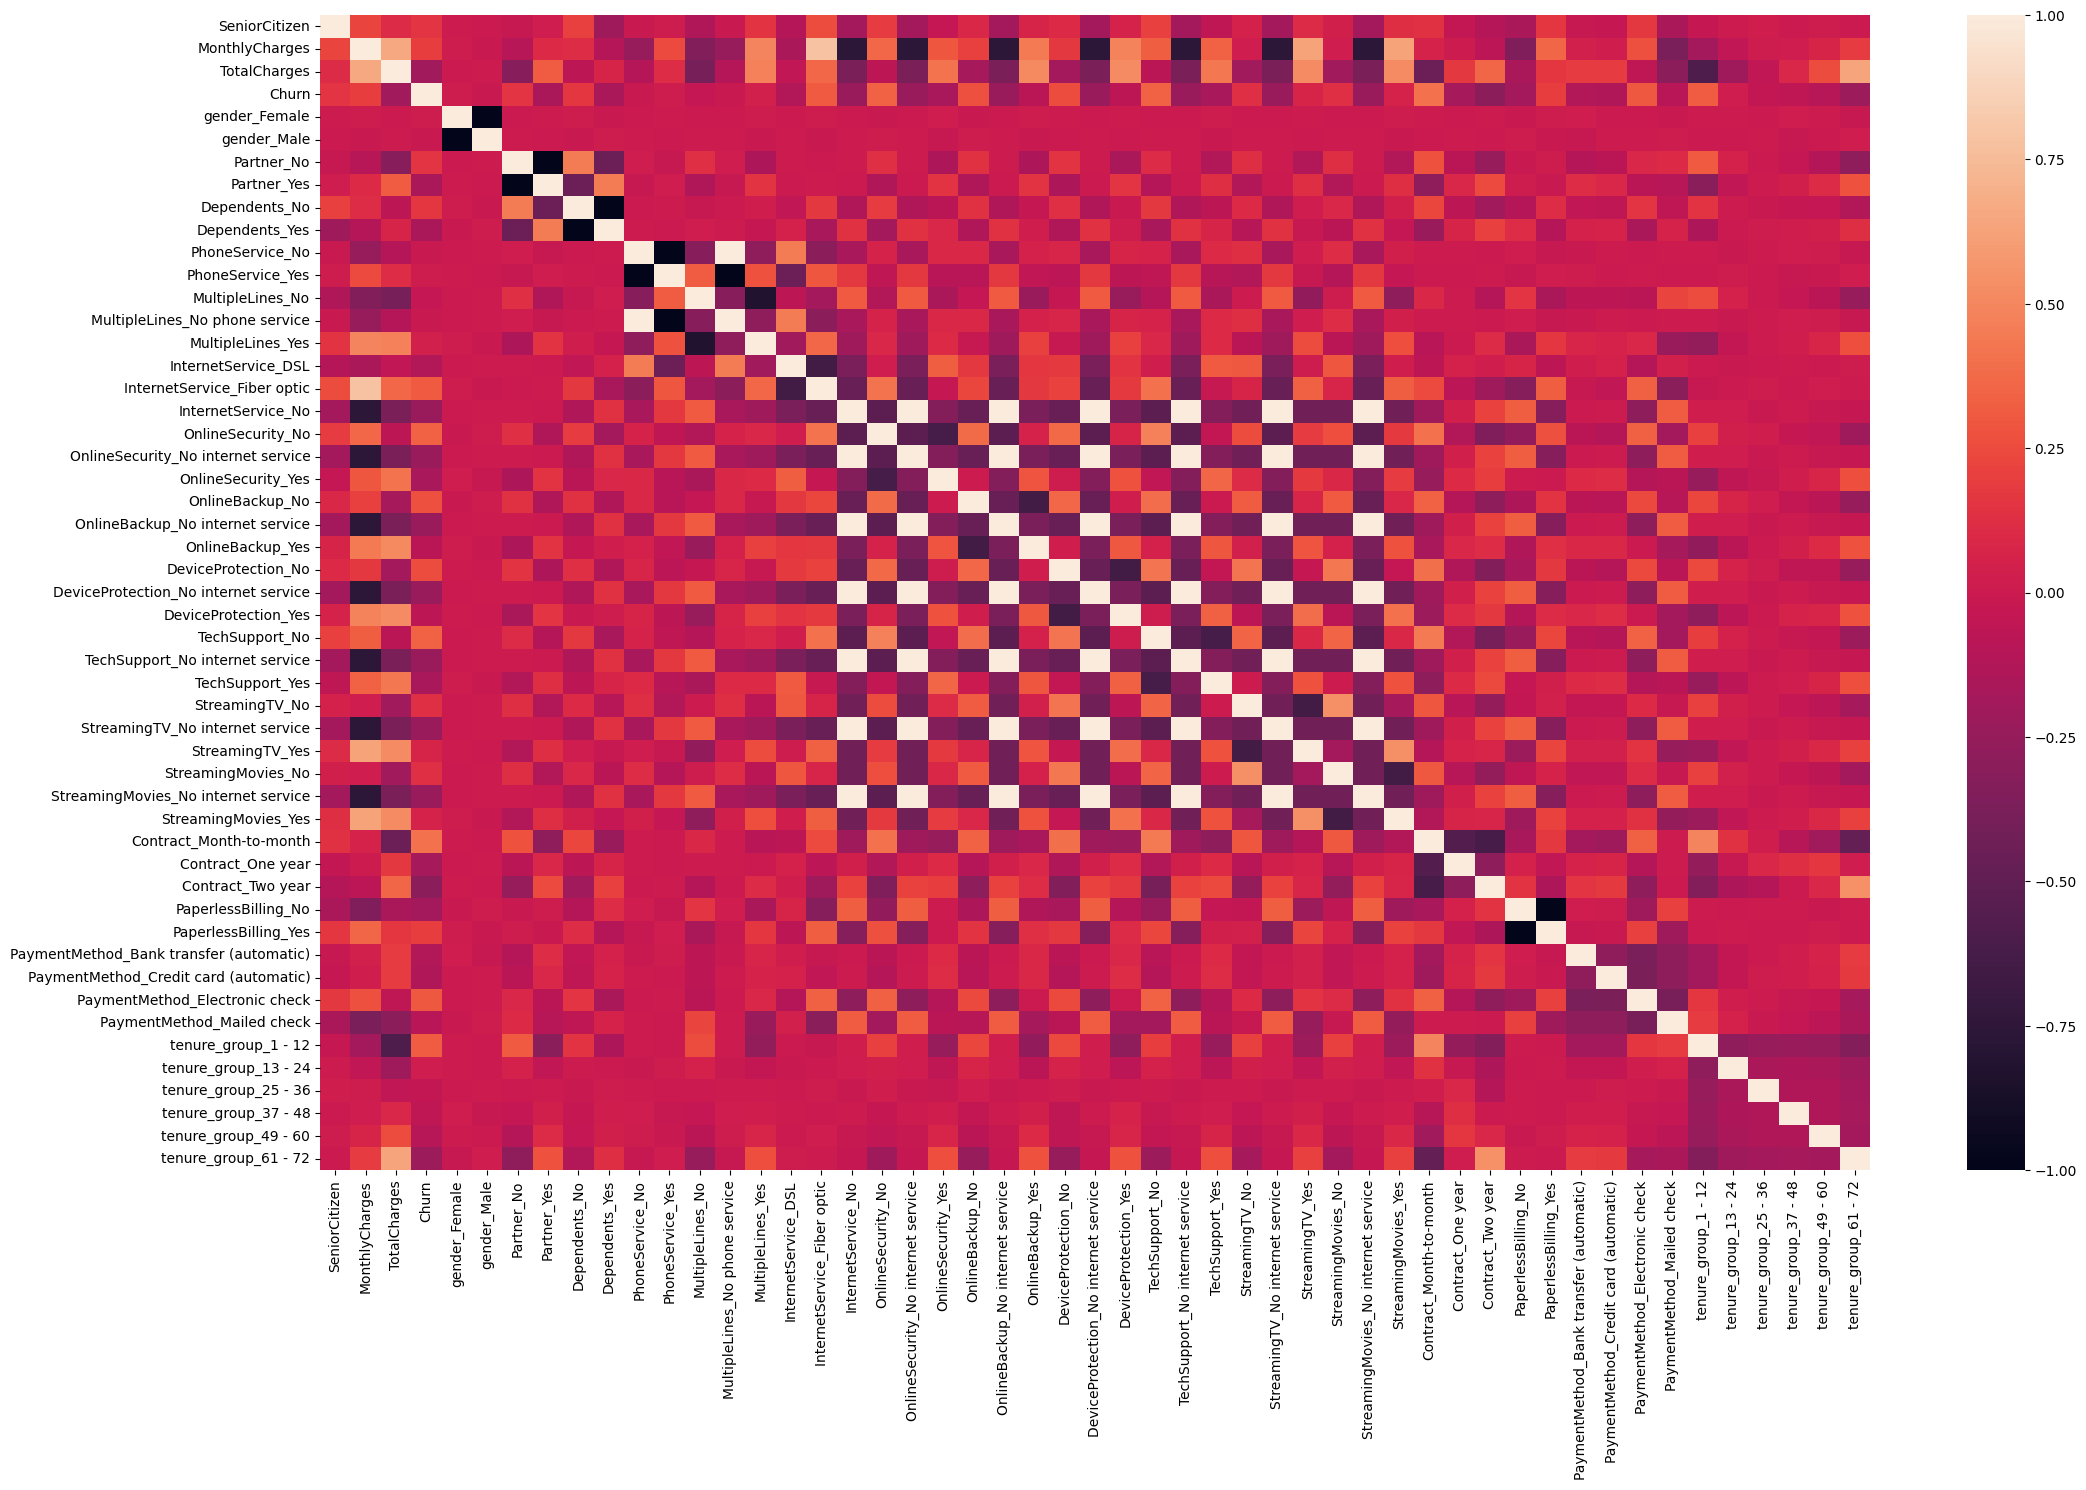

In [28]:
#CORRELATION HEATMAP
plt.figure(figsize=(25,15))
sns.heatmap(telco_new_data_dummies.corr())

In [29]:
# Created two new DataFrames: one for non-churned and churned customers
new_df1=telco_new_data.loc[telco_new_data["Churn"]==0]
new_df2=telco_new_data.loc[telco_new_data["Churn"]==1]

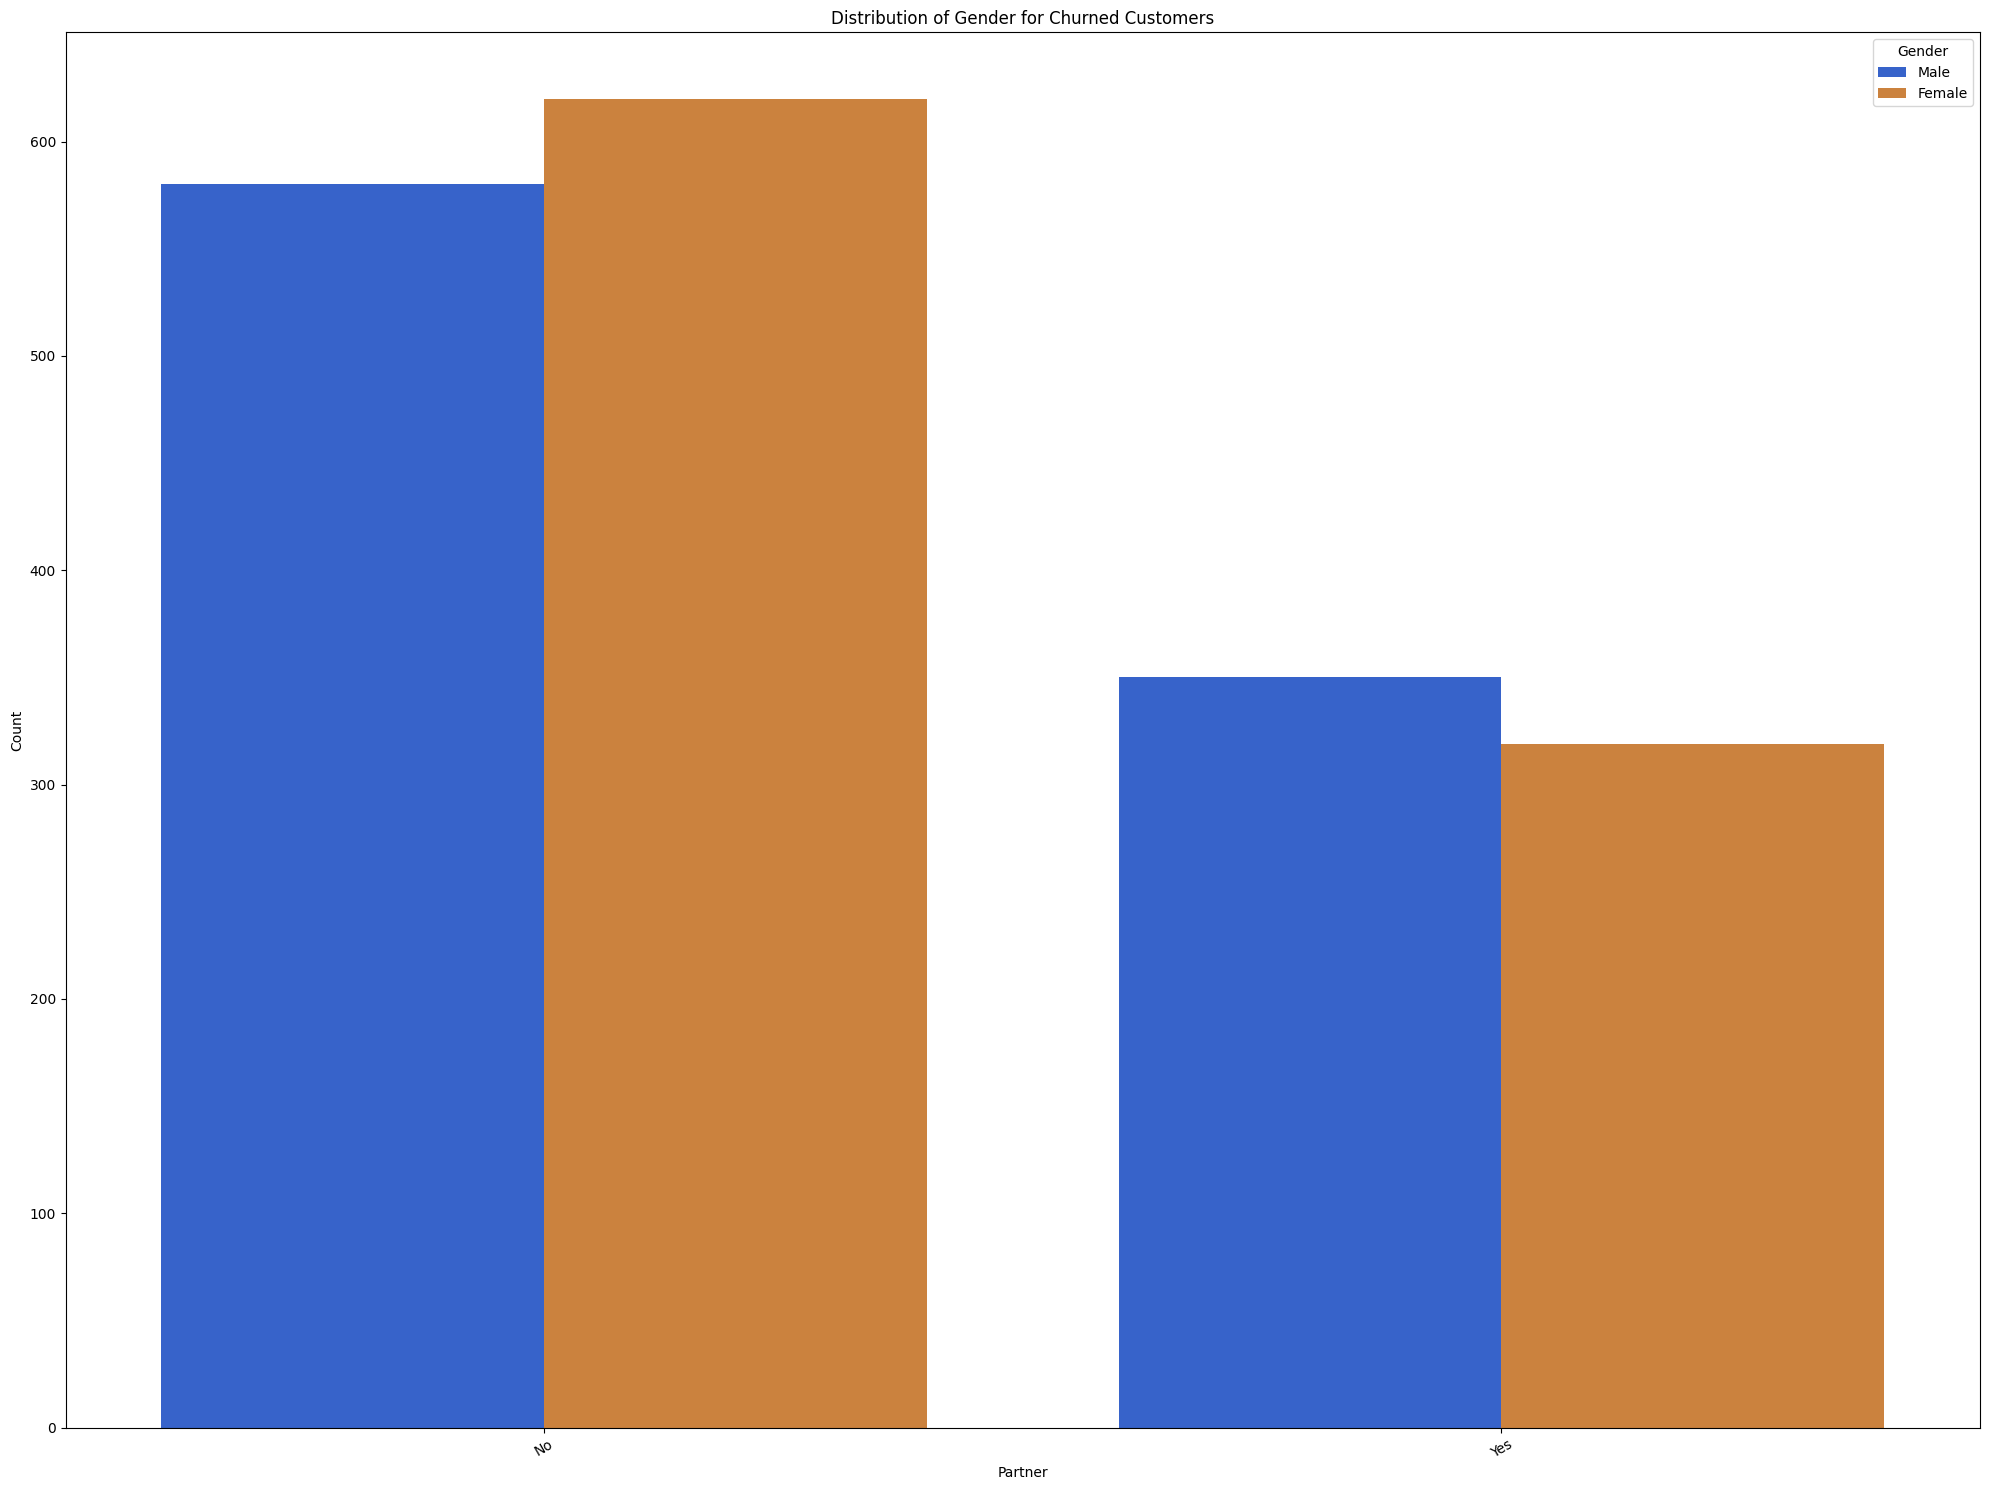

In [30]:
# Created a countplot to visualize the distribution of 'Partner' status, broken down by 'gender', for churned customers
plt.figure(figsize=(20,15))
ax=sns.countplot(data=new_df2,x='Partner',hue='gender',palette={"Male":"#1f59e2","Female":"#e28127"})

#ax.set_yscale("log")

plt.title("Distribution of Gender for Churned Customers")
plt.xlabel("Partner")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.legend(loc="upper right",title="Gender")
plt.tight_layout()
plt.show()

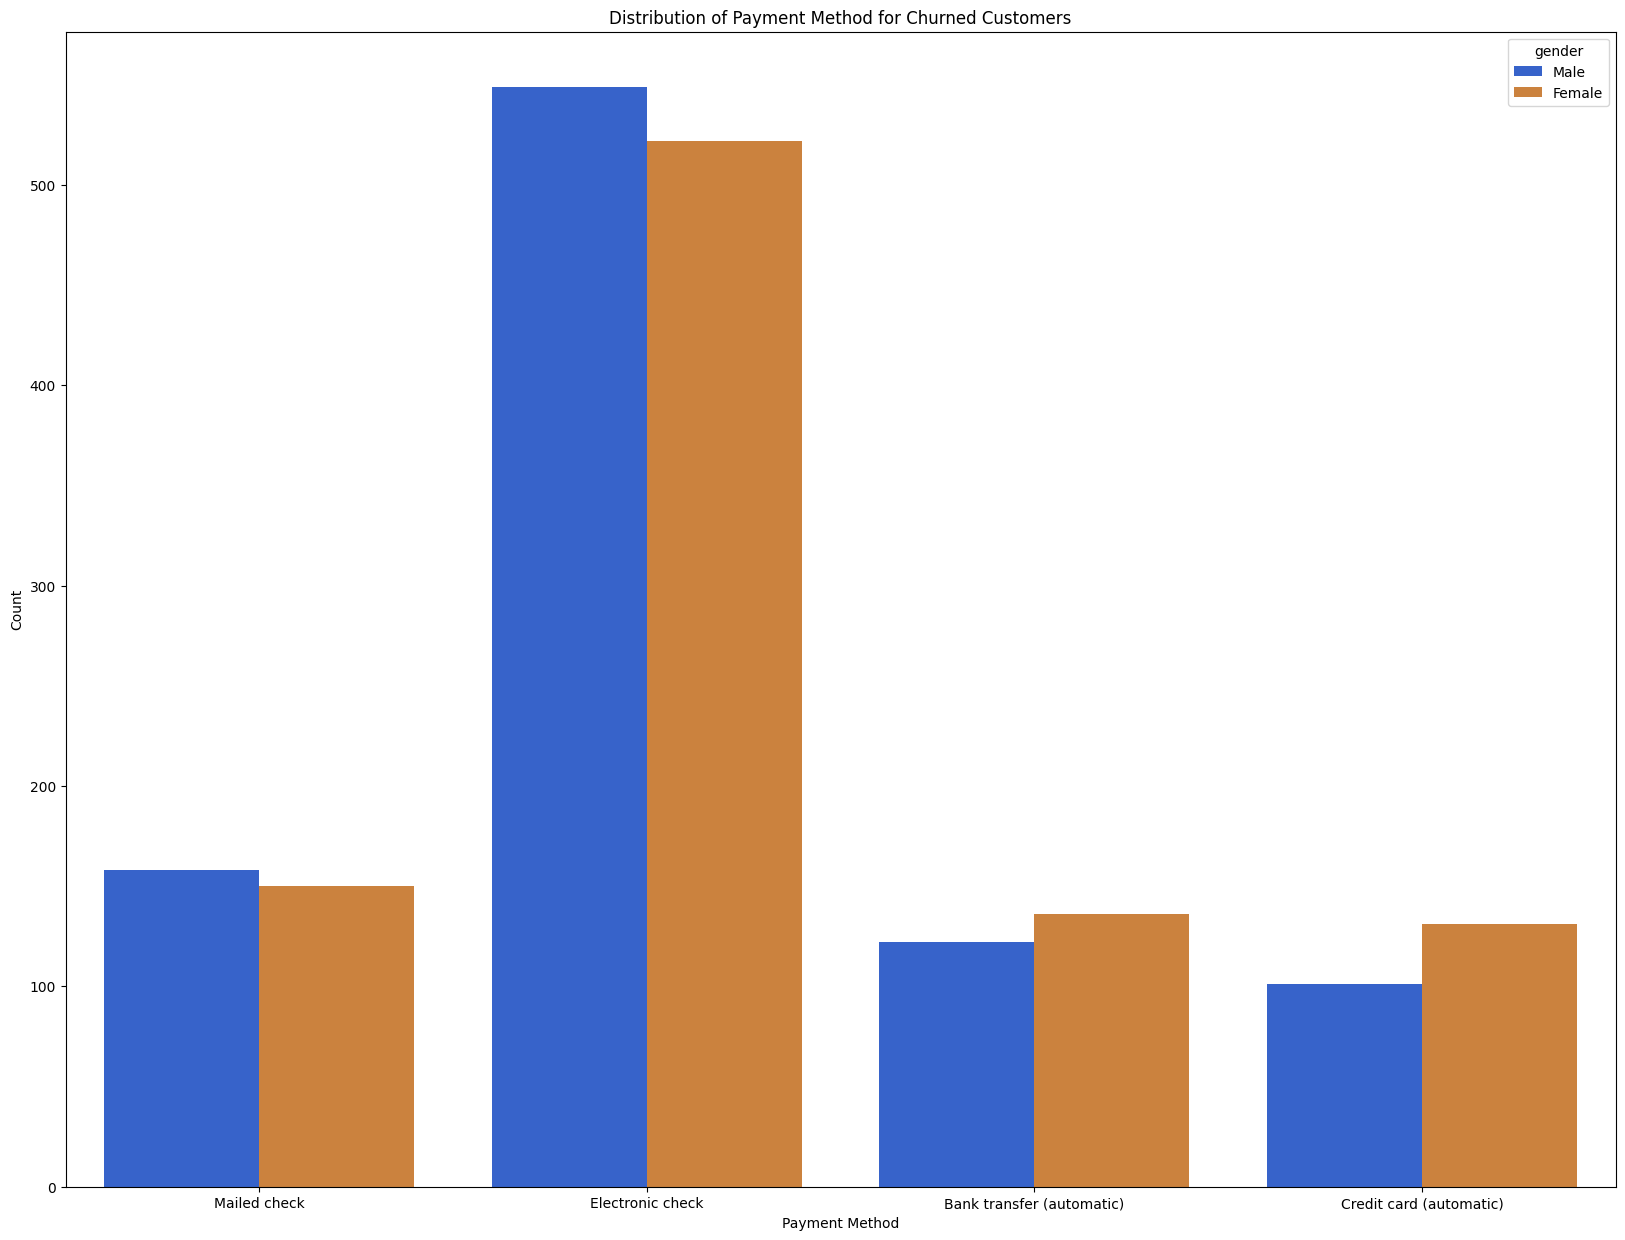

In [31]:
# Created a countplot to visualize the distribution of 'PaymentMethod', broken down by 'gender', for churned customers
plt.figure(figsize=(20,15))

ax=sns.countplot(data=new_df2,x='PaymentMethod',hue='gender',palette={"Male":"#1f59e2","Female":"#e28127"})

plt.title("Distribution of Payment Method for Churned Customers")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

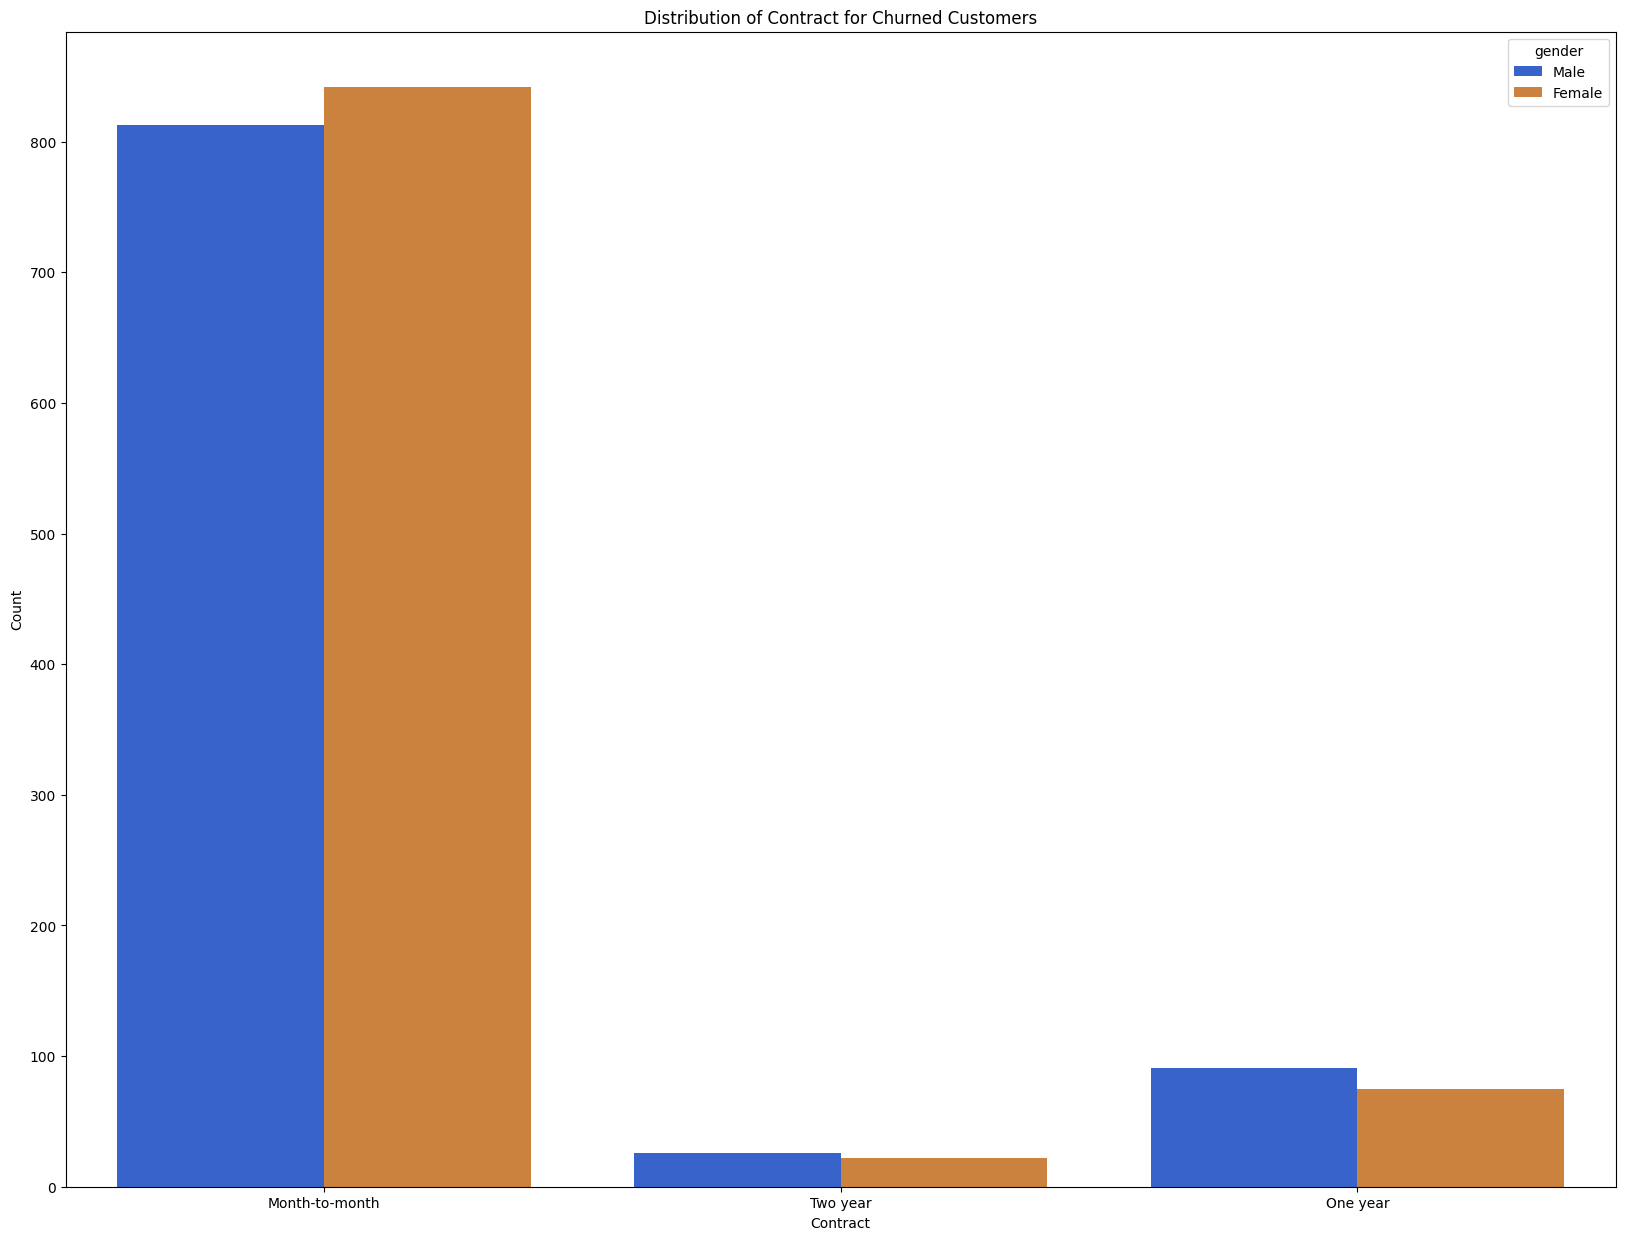

In [32]:
# Created a countplot to visualize the distribution of 'Contract' type, broken down by 'gender', for churned customers
plt.figure(figsize=(20,15))

ax=sns.countplot(data=new_df2,x='Contract',hue='gender',palette={"Male":"#1f59e2","Female":"#e28127"})

plt.title("Distribution of Contract for Churned Customers")
plt.xlabel("Contract")
plt.ylabel("Count")

plt.show()

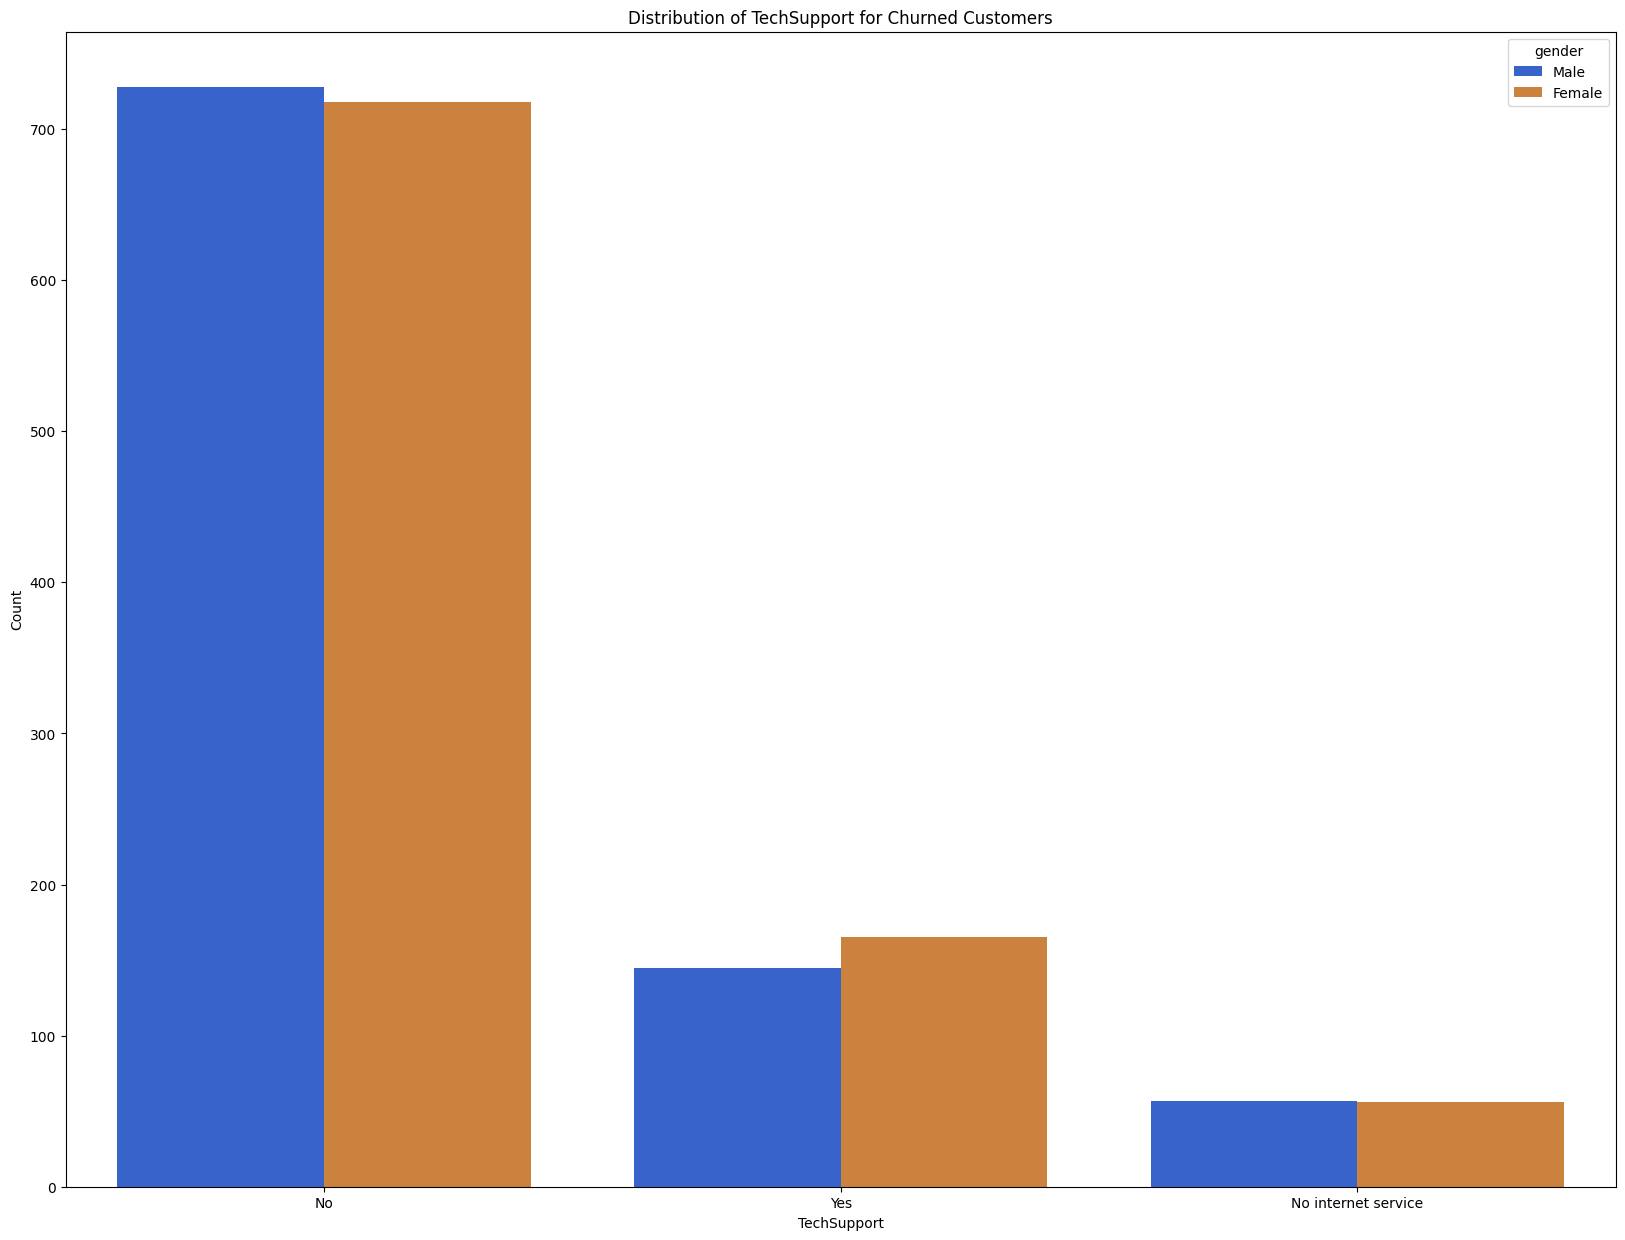

In [33]:
# Created a countplot to visualize the distribution of 'TechSupport' status, for churned customers
plt.figure(figsize=(20,15))

ax=sns.countplot(data=new_df2,x='TechSupport',hue='gender',palette={"Male":"#1f59e2","Female":"#e28127"})

plt.title("Distribution of TechSupport for Churned Customers")
plt.xlabel("TechSupport")
plt.ylabel("Count")

plt.show()

/tmp/ipykernel_726/3279272615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=telco_new_data, x='Churn', palette='viridis')


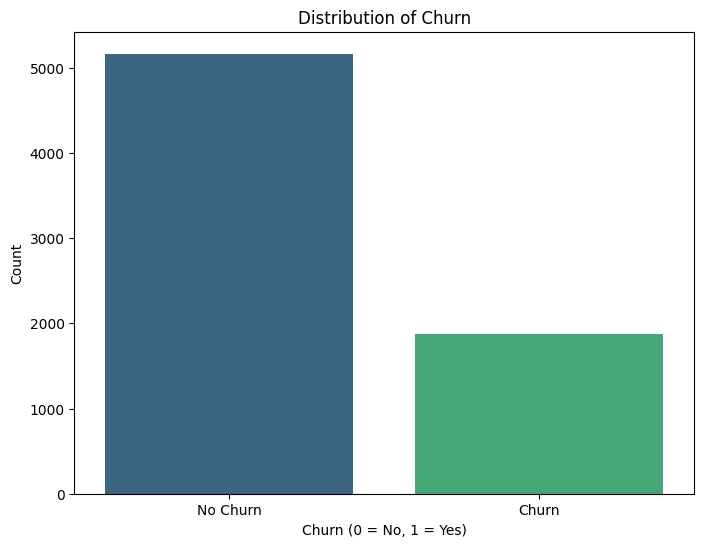

In [34]:
#COUNTPLOT FOR CHURNED VS NON CHURNED CUSTOMERS
plt.figure(figsize=(8, 6))
sns.countplot(data=telco_new_data, x='Churn', palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()